In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

In [18]:
x , _ = make_blobs(n_samples=100, centers=1, cluster_std=2, random_state=42)

In [19]:
def divisive_clustering(data,  
                        max_clusters=4):
    clusters = [data]
    labels = np.zeros(len(data),dtype=int)
    while len(clusters) < max_clusters:
        # ind the cluster with the largest number of points
        idx_to_split = np.argmax([len(c) for c in clusters])
        # this was the cluster we want to split next
        cluster_to_split = clusters.pop(idx_to_split)
        # get a new label to assign to the new cluster
        current_label = np.max(labels) + 1
        ##kmeans to split the cluster
        kmeans = KMeans(n_clusters=2, random_state=42)
        split_labels = kmeans.fit_predict(cluster_to_split)
        # divide the clusters into two based on kmeans data
        cluster1 = cluster_to_split[split_labels == 0]
        cluster2 = cluster_to_split[split_labels == 1]
        # add the new clusterrs back into the list
        clusters.append(cluster1)
        clusters.append(cluster2)
        ##label assignment
        label_indices = np.where([np.any(np.all(x == cluster_to_split, axis=1)) for x in data])[0]
        label_subset = split_labels
        labels[label_indices] = current_label
        labels[label_indices[label_subset == 0]] = current_label
        labels[label_indices[split_labels == 1]] = current_label+1
        
    return labels
        
    
        
        

In [20]:
cluster_labels = divisive_clustering(x, max_clusters = 4)

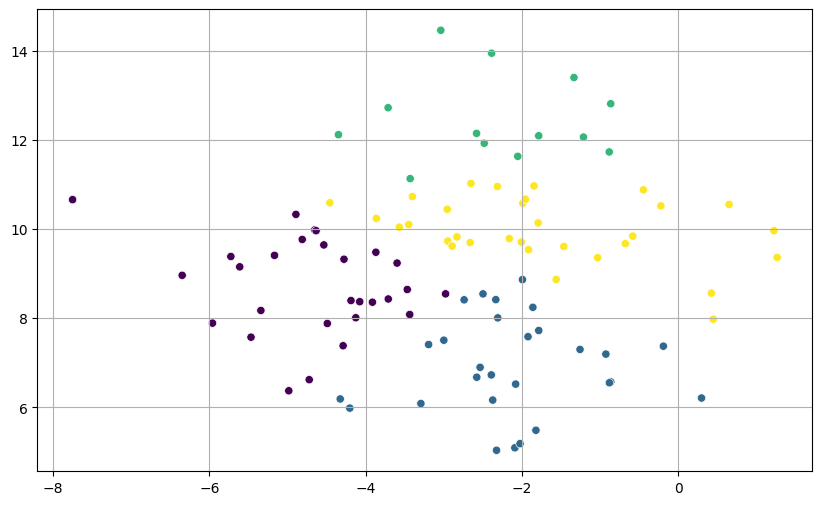

In [24]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=x[:,0], y=x[:,1], c=cluster_labels)
plt.grid(True)
plt.show()